In [2]:
# =============================================================================
# 01_DataLoader_Regime.ipynb — 레짐 분류 v4
# 목적: 4개 레짐(Bull/Bear/Recovery/Neutral) × MA 기간별 비교
#       + 이중 MA 크로스 + 거시 필터 일치율
# =============================================================================

# ── 셀 1: 환경 + 데이터 로드 ──────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── 경로 (SSOT) ──
QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"

# ── 기존 산출물 로드 ──
# 시장 레짐 지표 (01_DataLoader_Macro 산출물)
mkt = pd.read_parquet(INTERIM_DIR / "market_regime_indicators.parquet")
macro = pd.read_parquet(INTERIM_DIR / "macro_indicators.parquet")

# S&P500 가격 (regime 재계산 원본)
px_wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")

print("=== market_regime_indicators ===")
print(f"Shape: {mkt.shape}")
print(f"Columns: {list(mkt.columns)}")
print(f"Date range: {mkt.index.min()} ~ {mkt.index.max()}")
print()

print("=== macro_indicators ===")
print(f"Shape: {macro.shape}")
print(f"Columns: {list(macro.columns)}")
print(f"Date range: {macro.index.min()} ~ {macro.index.max()}")
print()

# ── EW 지수 생성 (레짐 판단용 기준 가격) ──
# 기존과 동일: S&P500 EW 일간 수익률 → 누적
ret_1d = px_wide.pct_change()
ew_ret_1d = ret_1d.mean(axis=1)
ew_price = (1 + ew_ret_1d).cumprod()
ew_price.name = "ew_price"

# 월말 리샘플
ew_monthly = ew_price.resample("ME").last().to_frame("ew_price")

print(f"EW Price: {len(ew_price)} days, {len(ew_monthly)} months")
print(f"  range: {ew_monthly.index.min().strftime('%Y-%m')} ~ {ew_monthly.index.max().strftime('%Y-%m')}")
print()
print("셀 1 완료 — 데이터 로드 OK")


=== market_regime_indicators ===
Shape: (769, 18)
Columns: ['price', 'ma_6m', 'ma_12m', 'price_vs_ma6', 'price_vs_ma12', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'volatility', 'drawdown', 'rally_from_low', 'ma6_slope', 'ma12_slope', 'regime', 'regime_v2', 'regime_v3', 'regime_final']
Date range: 1962-01-31 00:00:00 ~ 2026-01-31 00:00:00

=== macro_indicators ===
Shape: (314, 7)
Columns: ['UNRATE', 'T10Y2Y', 'T10Y3M', 'BAMLH0A0HYM2', 'VIXCLS', 'FEDFUNDS', 'CPIAUCSL']
Date range: 2000-01-31 00:00:00 ~ 2026-02-28 00:00:00

EW Price: 16132 days, 770 months
  range: 1962-01 ~ 2026-02

셀 1 완료 — 데이터 로드 OK


In [3]:
# ── 셀 2: 4개 레짐 정의 함수 ──────────────────────────────────────────────
# Bull / Bear / Recovery / Neutral
# 입력: ew_monthly (월말 EW 가격), MA 윈도우
# =============================================================================

def calc_regime_4(price_series, ma_window, mom_window=3, dd_threshold=-0.10):
    """
    4-regime classification based on single MA.
    
    Parameters
    ----------
    price_series : pd.Series  — 월말 가격 (index=datetime)
    ma_window    : int         — MA 기간 (월 단위: 3, 6, 9, 12)
    mom_window   : int         — 모멘텀 계산 기간 (기본 3개월)
    dd_threshold : float       — Bear 판정용 DD 임계값 (기본 -10%)
    
    Returns
    -------
    pd.DataFrame with columns: [price, ma, price_vs_ma, mom, drawdown, regime]
    """
    df = pd.DataFrame(index=price_series.index)
    df["price"] = price_series
    
    # MA
    df["ma"] = df["price"].rolling(ma_window, min_periods=ma_window).mean()
    df["price_vs_ma"] = df["price"] / df["ma"] - 1  # 양수 = MA 위
    
    # 모멘텀 (mom_window 개월 수익률)
    df["mom"] = df["price"].pct_change(mom_window)
    
    # Drawdown (전고점 대비)
    rolling_max = df["price"].expanding().max()
    df["drawdown"] = df["price"] / rolling_max - 1
    
    # ── 4개 레짐 분류 ──
    above_ma = df["price_vs_ma"] > 0
    mom_pos  = df["mom"] > 0
    mom_neg  = df["mom"] < 0
    dd_deep  = df["drawdown"] < dd_threshold
    
    conditions = []
    # Bull: MA 위 + 모멘텀 양수
    conditions.append(("Bull",     above_ma & mom_pos))
    # Bear: MA 아래 + (모멘텀 음수 OR DD 심화)
    conditions.append(("Bear",     ~above_ma & (mom_neg | dd_deep)))
    # Recovery: MA 아래이지만 모멘텀 양수 (반등 중)
    conditions.append(("Recovery", ~above_ma & mom_pos))
    # Neutral: 나머지 (MA 위인데 모멘텀 음수 = 고점 횡보/초기 둔화)
    
    df["regime"] = "Neutral"
    # 역순 적용 (먼저 적용된 게 우선)
    for name, mask in conditions:
        df.loc[mask, "regime"] = name
    
    df = df.dropna(subset=["ma"])  # MA warmup 제거
    return df


def calc_regime_dual_ma(price_series, short_window, long_window, 
                         mom_window=3, dd_threshold=-0.10):
    """
    4-regime classification based on dual MA crossover.
    
    Bull:     short MA > long MA + 모멘텀 양수
    Bear:     short MA < long MA + (모멘텀 음수 OR DD 심화)
    Recovery: short MA < long MA + 모멘텀 양수
    Neutral:  나머지
    """
    df = pd.DataFrame(index=price_series.index)
    df["price"] = price_series
    
    # 이중 MA
    df["ma_short"] = df["price"].rolling(short_window, min_periods=short_window).mean()
    df["ma_long"]  = df["price"].rolling(long_window, min_periods=long_window).mean()
    df["ma_cross"] = df["ma_short"] / df["ma_long"] - 1  # 양수 = 골든크로스
    
    # 모멘텀 + DD
    df["mom"] = df["price"].pct_change(mom_window)
    rolling_max = df["price"].expanding().max()
    df["drawdown"] = df["price"] / rolling_max - 1
    
    # ── 분류 ──
    golden = df["ma_cross"] > 0
    mom_pos = df["mom"] > 0
    mom_neg = df["mom"] < 0
    dd_deep = df["drawdown"] < dd_threshold
    
    df["regime"] = "Neutral"
    df.loc[golden & mom_pos, "regime"]  = "Bull"
    df.loc[~golden & (mom_neg | dd_deep), "regime"] = "Bear"
    df.loc[~golden & mom_pos, "regime"] = "Recovery"
    
    df = df.dropna(subset=["ma_long"])
    return df


# ── 테스트: 6개월 MA 기준으로 한번 돌려보기 ──
test = calc_regime_4(ew_monthly["ew_price"], ma_window=6)
print("=== 4-Regime (MA=6) 테스트 ===")
print(f"기간: {test.index.min().strftime('%Y-%m')} ~ {test.index.max().strftime('%Y-%m')}")
print(f"총 {len(test)}개월")
print()
print("레짐 분포:")
print(test["regime"].value_counts().sort_index())
print()
print("레짐 비율:")
print((test["regime"].value_counts(normalize=True).sort_index() * 100).round(1))

print("\n셀 2 완료 — 레짐 분류 함수 정의 OK")

=== 4-Regime (MA=6) 테스트 ===
기간: 1962-06 ~ 2026-02
총 765개월

레짐 분포:
regime
Bear        151
Bull        551
Neutral      44
Recovery     19
Name: count, dtype: int64

레짐 비율:
regime
Bear        19.7
Bull        72.0
Neutral      5.8
Recovery     2.5
Name: proportion, dtype: float64

셀 2 완료 — 레짐 분류 함수 정의 OK


4-Regime 분포 비교 (%, 모멘텀=3M, DD임계=-10%)
           Bull  Bear  Recovery  Neutral  n_months
MA_window                                         
3          62.6  17.8      11.6      7.9       768
6          72.0  19.7       2.5      5.8       765
9          71.9  16.0       2.9      9.2       762
12         71.7  13.4       3.2     11.7       759

레짐 전환 빈도 (월간 전환 횟수 / 총 월수):
---------------------------------------------
  MA= 3:  전환 313회 / 768월  →  빈도 0.408  |  평균 체류 2.4개월
  MA= 6:  전환 185회 / 765월  →  빈도 0.242  |  평균 체류 4.1개월
  MA= 9:  전환 186회 / 762월  →  빈도 0.244  |  평균 체류 4.1개월
  MA=12:  전환 177회 / 759월  →  빈도 0.233  |  평균 체류 4.3개월


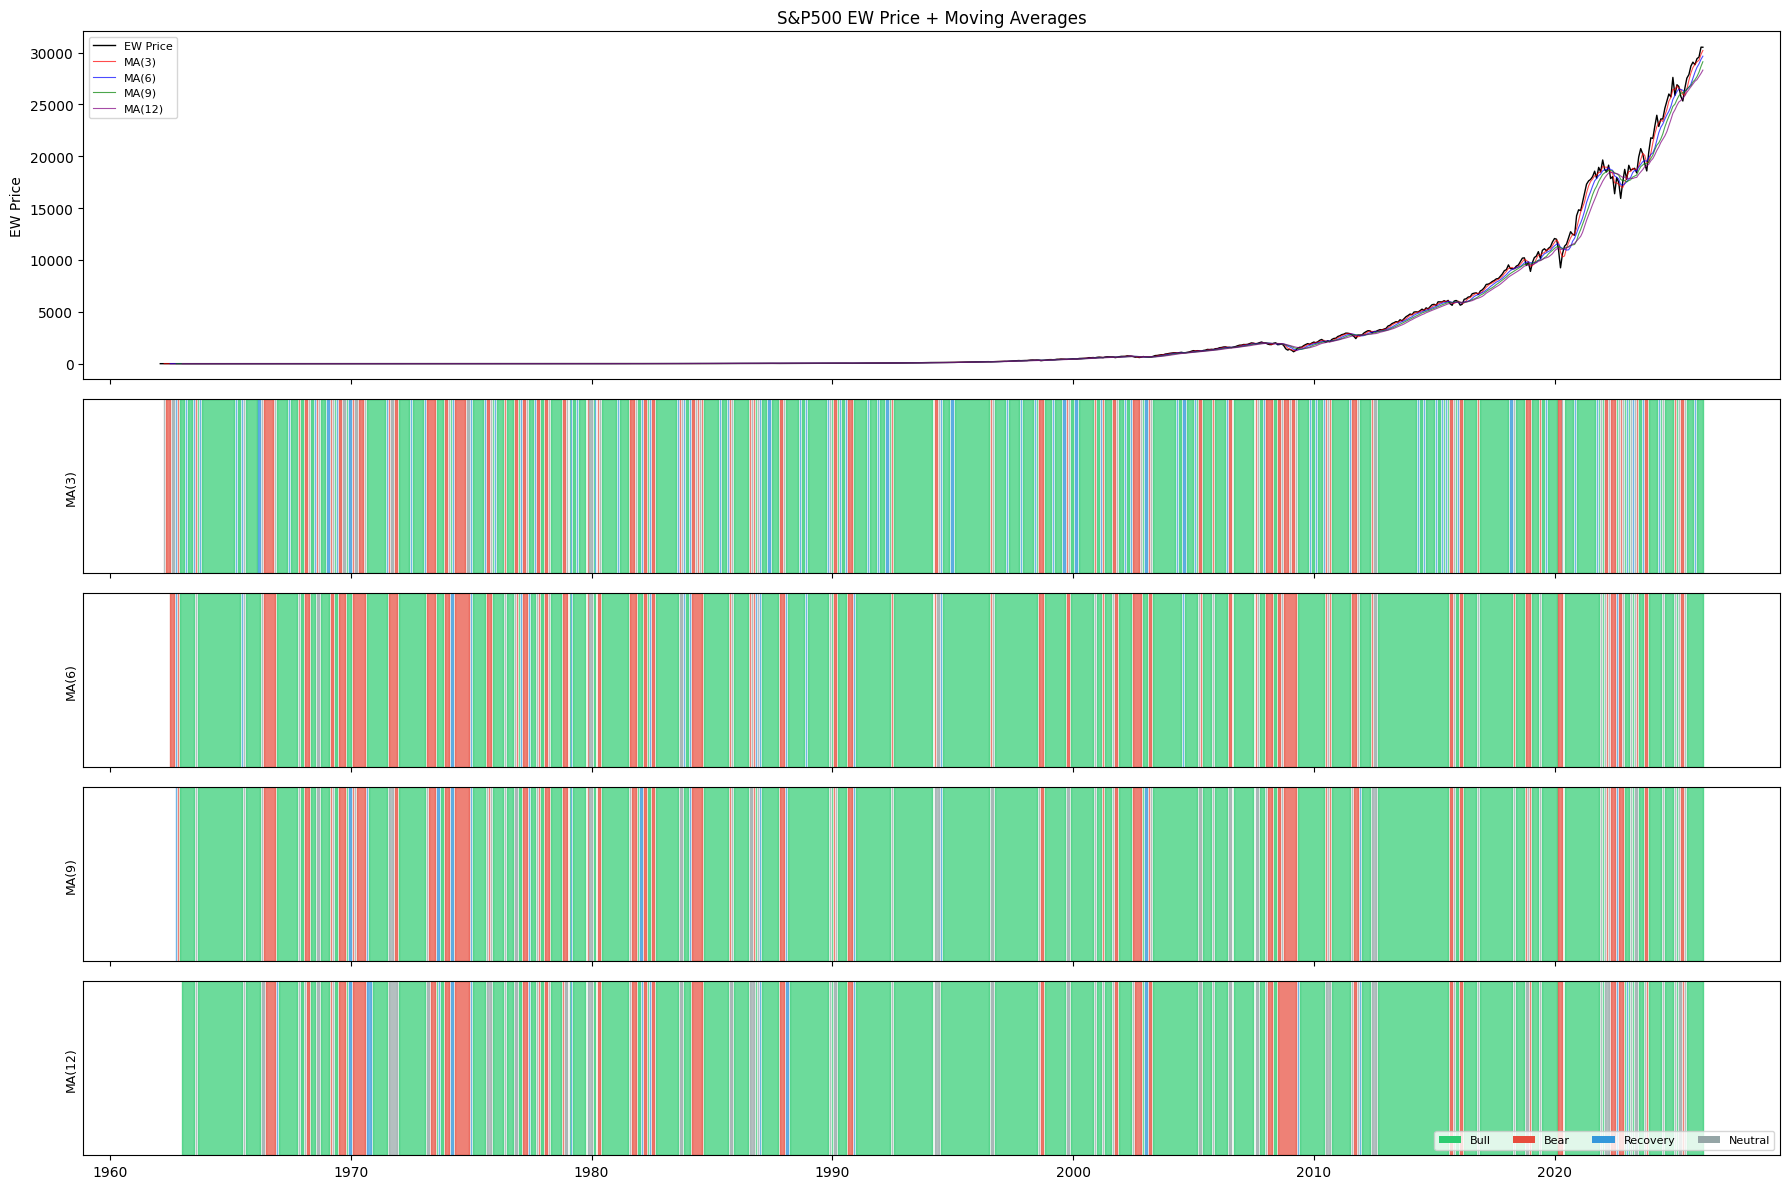


셀 3 완료 — MA 기간별 레짐 비교 OK


In [4]:
# ── 셀 3: MA 기간별 테스트 (3/6/9/12개월 SMA) ────────────────────────────
# =============================================================================

MA_WINDOWS = [3, 6, 9, 12]
MOM_WINDOW = 3          # 모멘텀 3개월 고정
DD_THRESHOLD = -0.10    # DD -10% 고정

price = ew_monthly["ew_price"]

# ── 전체 결과 저장 ──
regime_results = {}     # {f"MA_{w}": DataFrame}

for w in MA_WINDOWS:
    r = calc_regime_4(price, ma_window=w, mom_window=MOM_WINDOW, 
                       dd_threshold=DD_THRESHOLD)
    r = r.rename(columns={"regime": f"regime_MA{w}"})
    regime_results[f"MA_{w}"] = r
    
# ── 분포 비교 테이블 ──
dist_rows = []
for w in MA_WINDOWS:
    col = f"regime_MA{w}"
    s = regime_results[f"MA_{w}"][col].value_counts(normalize=True) * 100
    row = {"MA_window": w}
    for regime in ["Bull", "Bear", "Recovery", "Neutral"]:
        row[regime] = s.get(regime, 0)
    row["n_months"] = len(regime_results[f"MA_{w}"])
    dist_rows.append(row)

dist_df = pd.DataFrame(dist_rows).set_index("MA_window")
print("=" * 65)
print("4-Regime 분포 비교 (%, 모멘텀=3M, DD임계=-10%)")
print("=" * 65)
print(dist_df.round(1).to_string())
print()

# ── 전환 빈도 (regime switch / 총 월 수) ──
print("레짐 전환 빈도 (월간 전환 횟수 / 총 월수):")
print("-" * 45)
for w in MA_WINDOWS:
    col = f"regime_MA{w}"
    regimes = regime_results[f"MA_{w}"][col]
    switches = (regimes != regimes.shift()).sum() - 1  # 첫 행 제외
    freq = switches / len(regimes)
    avg_duration = len(regimes) / (switches + 1)
    print(f"  MA={w:2d}:  전환 {switches:3d}회 / {len(regimes)}월"
          f"  →  빈도 {freq:.3f}  |  평균 체류 {avg_duration:.1f}개월")

# ── 시각화: 4개 MA 레짐 타임라인 ──
fig, axes = plt.subplots(len(MA_WINDOWS) + 1, 1, figsize=(18, 12), 
                          sharex=True, gridspec_kw={"height_ratios": [2] + [1]*len(MA_WINDOWS)})

# 상단: 가격 + MA
ax0 = axes[0]
ax0.plot(ew_monthly.index, ew_monthly["ew_price"], "k-", lw=1, label="EW Price")
colors_ma = {3: "red", 6: "blue", 9: "green", 12: "purple"}
for w in MA_WINDOWS:
    ma_col = regime_results[f"MA_{w}"]["ma"]
    ax0.plot(ma_col.index, ma_col, "-", color=colors_ma[w], lw=0.8, 
             alpha=0.7, label=f"MA({w})")
ax0.set_ylabel("EW Price")
ax0.legend(loc="upper left", fontsize=8)
ax0.set_title("S&P500 EW Price + Moving Averages")

# 하단: 각 MA별 레짐 컬러맵
regime_colors = {"Bull": "#2ecc71", "Bear": "#e74c3c", 
                 "Recovery": "#3498db", "Neutral": "#95a5a6"}

for i, w in enumerate(MA_WINDOWS):
    ax = axes[i + 1]
    col = f"regime_MA{w}"
    df_r = regime_results[f"MA_{w}"]
    
    for regime, color in regime_colors.items():
        mask = df_r[col] == regime
        ax.fill_between(df_r.index, 0, 1, where=mask, 
                        color=color, alpha=0.7, step="post")
    
    ax.set_ylabel(f"MA({w})", fontsize=9)
    ax.set_yticks([])
    ax.set_ylim(0, 1)

# 범례 (마지막 축에)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in regime_colors.items()]
axes[-1].legend(handles=legend_elements, loc="lower right", ncol=4, fontsize=8)

plt.tight_layout()
plt.savefig(str(INTERIM_DIR / "regime_v4_ma_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\n셀 3 완료 — MA 기간별 레짐 비교 OK")

In [5]:
# ── 셀 4: 이중 MA 테스트 (단기/장기 크로스) ──────────────────────────────
# =============================================================================

DUAL_MA_COMBOS = [
    (3, 6),
    (3, 9),
    (3, 12),
    (6, 9),
    (6, 12),
]

dual_results = {}

for short_w, long_w in DUAL_MA_COMBOS:
    key = f"DMA_{short_w}_{long_w}"
    r = calc_regime_dual_ma(price, short_window=short_w, long_window=long_w,
                             mom_window=MOM_WINDOW, dd_threshold=DD_THRESHOLD)
    r = r.rename(columns={"regime": f"regime_{key}"})
    dual_results[key] = r

# ── 분포 비교 ──
dual_dist_rows = []
for short_w, long_w in DUAL_MA_COMBOS:
    key = f"DMA_{short_w}_{long_w}"
    col = f"regime_{key}"
    s = dual_results[key][col].value_counts(normalize=True) * 100
    row = {"combo": f"{short_w}/{long_w}"}
    for regime in ["Bull", "Bear", "Recovery", "Neutral"]:
        row[regime] = s.get(regime, 0)
    row["n_months"] = len(dual_results[key])
    dual_dist_rows.append(row)

dual_dist_df = pd.DataFrame(dual_dist_rows).set_index("combo")
print("=" * 65)
print("이중 MA 4-Regime 분포 비교 (%, 모멘텀=3M, DD임계=-10%)")
print("=" * 65)
print(dual_dist_df.round(1).to_string())
print()

# ── 전환 빈도 ──
print("이중 MA 전환 빈도:")
print("-" * 55)
for short_w, long_w in DUAL_MA_COMBOS:
    key = f"DMA_{short_w}_{long_w}"
    col = f"regime_{key}"
    regimes = dual_results[key][col]
    switches = (regimes != regimes.shift()).sum() - 1
    freq = switches / len(regimes)
    avg_dur = len(regimes) / (switches + 1)
    print(f"  DMA {short_w:2d}/{long_w:2d}:  전환 {switches:3d}회 / {len(regimes)}월"
          f"  →  빈도 {freq:.3f}  |  평균 체류 {avg_dur:.1f}개월")

# ── 단일 MA vs 이중 MA 통합 비교 ──
print()
print("=" * 65)
print("전체 비교: 단일 MA + 이중 MA")
print("=" * 65)

all_rows = []
# 단일 MA
for w in MA_WINDOWS:
    col = f"regime_MA{w}"
    s = regime_results[f"MA_{w}"][col].value_counts(normalize=True) * 100
    regimes = regime_results[f"MA_{w}"][col]
    switches = (regimes != regimes.shift()).sum() - 1
    row = {
        "method": f"MA({w})",
        "Bull": s.get("Bull", 0),
        "Bear": s.get("Bear", 0),
        "Recovery": s.get("Recovery", 0),
        "Neutral": s.get("Neutral", 0),
        "전환빈도": switches / len(regimes),
        "평균체류": len(regimes) / (switches + 1),
    }
    all_rows.append(row)

# 이중 MA
for short_w, long_w in DUAL_MA_COMBOS:
    key = f"DMA_{short_w}_{long_w}"
    col = f"regime_{key}"
    s = dual_results[key][col].value_counts(normalize=True) * 100
    regimes = dual_results[key][col]
    switches = (regimes != regimes.shift()).sum() - 1
    row = {
        "method": f"DMA({short_w}/{long_w})",
        "Bull": s.get("Bull", 0),
        "Bear": s.get("Bear", 0),
        "Recovery": s.get("Recovery", 0),
        "Neutral": s.get("Neutral", 0),
        "전환빈도": switches / len(regimes),
        "평균체류": len(regimes) / (switches + 1),
    }
    all_rows.append(row)

compare_df = pd.DataFrame(all_rows).set_index("method")
print(compare_df.round(2).to_string())

print("\n셀 4 완료 — 이중 MA 테스트 OK")

이중 MA 4-Regime 분포 비교 (%, 모멘텀=3M, DD임계=-10%)
       Bull  Bear  Recovery  Neutral  n_months
combo                                         
3/6    68.9  16.1       5.6      9.4       765
3/9    68.4  12.6       6.4     12.6       762
3/12   69.0  10.7       5.8     14.5       759
6/9    65.2   8.9       9.6     16.3       762
6/12   66.7   7.4       8.2     17.8       759

이중 MA 전환 빈도:
-------------------------------------------------------
  DMA  3/ 6:  전환 209회 / 765월  →  빈도 0.273  |  평균 체류 3.6개월
  DMA  3/ 9:  전환 191회 / 762월  →  빈도 0.251  |  평균 체류 4.0개월
  DMA  3/12:  전환 180회 / 759월  →  빈도 0.237  |  평균 체류 4.2개월
  DMA  6/ 9:  전환 191회 / 762월  →  빈도 0.251  |  평균 체류 4.0개월
  DMA  6/12:  전환 164회 / 759월  →  빈도 0.216  |  평균 체류 4.6개월

전체 비교: 단일 MA + 이중 MA
            Bull   Bear  Recovery  Neutral  전환빈도  평균체류
method                                                
MA(3)      62.63  17.84     11.59     7.94  0.41  2.45
MA(6)      72.03  19.74      2.48     5.75  0.24  4.11
MA(9)      71.92  16.01  

In [6]:
# ── 셀 4.1: DD 임계값 민감도 테스트 ──────────────────────────────────────
# MA=6 고정, DD threshold만 변경
# =============================================================================

DD_THRESHOLDS = [-0.05, -0.10, -0.15, -0.20, -0.25]
MA_FIX = 6

sens_rows = []
for dd_t in DD_THRESHOLDS:
    r = calc_regime_4(price, ma_window=MA_FIX, mom_window=MOM_WINDOW, 
                       dd_threshold=dd_t)
    s = r["regime"].value_counts(normalize=True) * 100
    switches = (r["regime"] != r["regime"].shift()).sum() - 1
    
    # Recovery 중 DD가 threshold 넘는 건수 (DD 조건으로 Bear 전환되는 케이스)
    rec_mask = (~(r["price_vs_ma"] > 0)) & (r["mom"] > 0)  # Recovery 후보
    dd_override = rec_mask & (r["drawdown"] < dd_t)          # 근데 DD로 Bear 됨
    
    row = {
        "DD_threshold": f"{dd_t:.0%}",
        "Bull": s.get("Bull", 0),
        "Bear": s.get("Bear", 0),
        "Recovery": s.get("Recovery", 0),
        "Neutral": s.get("Neutral", 0),
        "전환빈도": switches / len(r),
        "평균체류": len(r) / (switches + 1),
        "DD→Bear전환": dd_override.sum(),  # Recovery였을텐데 DD때문에 Bear된 월수
    }
    sens_rows.append(row)

sens_df = pd.DataFrame(sens_rows).set_index("DD_threshold")
print("=" * 75)
print(f"DD 임계값 민감도 (MA={MA_FIX} 고정, 모멘텀=3M)")
print("=" * 75)
print(sens_df.round(2).to_string())
print()
print("DD→Bear전환: Recovery 조건(MA아래+mom양수)이지만 DD가 깊어서 Bear로 분류된 월 수")
print()

# ── 핵심 비교: DD=-10% vs DD 조건 아예 없앤 버전 ──
r_no_dd = calc_regime_4(price, ma_window=MA_FIX, mom_window=MOM_WINDOW, 
                          dd_threshold=-9.99)  # -999% = 사실상 DD 조건 무력화
s_no_dd = r_no_dd["regime"].value_counts(normalize=True) * 100
switches_no_dd = (r_no_dd["regime"] != r_no_dd["regime"].shift()).sum() - 1

print("-" * 75)
print("참고: DD 조건 완전 제거 시 (threshold=-999%)")
print(f"  Bull={s_no_dd.get('Bull',0):.1f}%  Bear={s_no_dd.get('Bear',0):.1f}%  "
      f"Recovery={s_no_dd.get('Recovery',0):.1f}%  Neutral={s_no_dd.get('Neutral',0):.1f}%")
print(f"  전환빈도={switches_no_dd/len(r_no_dd):.3f}  평균체류={len(r_no_dd)/(switches_no_dd+1):.1f}개월")

print("\n셀 4.1 완료 — DD 민감도 테스트 OK")

DD 임계값 민감도 (MA=6 고정, 모멘텀=3M)
               Bull   Bear  Recovery  Neutral  전환빈도  평균체류  DD→Bear전환
DD_threshold                                                        
-5%           72.03  19.74      2.48     5.75  0.24  4.11         11
-10%          72.03  19.74      2.48     5.75  0.24  4.11          6
-15%          72.03  19.74      2.48     5.75  0.24  4.11          4
-20%          72.03  19.74      2.48     5.75  0.24  4.11          1
-25%          72.03  19.74      2.48     5.75  0.24  4.11          1

DD→Bear전환: Recovery 조건(MA아래+mom양수)이지만 DD가 깊어서 Bear로 분류된 월 수

---------------------------------------------------------------------------
참고: DD 조건 완전 제거 시 (threshold=-999%)
  Bull=72.0%  Bear=19.7%  Recovery=2.5%  Neutral=5.8%
  전환빈도=0.242  평균체류=4.1개월

셀 4.1 완료 — DD 민감도 테스트 OK


레짐별 EW 수익률 통계 (MA=6, 4-Regime)
          n_months  mean_ret(%)  median_ret(%)  std(%)  sharpe_ann  hit_rate(%)  worst(%)  best(%)
regime                                                                                            
Bull           551         2.74           2.68    3.56        2.67        77.13     -6.66    17.94
Bear           151        -2.78          -3.01    5.77       -1.67        27.81    -22.92    17.45
Recovery        19        -0.39          -2.08    4.67       -0.29        26.32     -5.02     9.87
Neutral         44         1.26           0.82    4.02        1.09        59.09     -6.25    13.28
ALL            765         1.49           1.76    4.68        1.10        65.10    -22.92    17.94

레짐 전환 매트릭스 (from → to, 횟수)
regime    Bear  Bull  Neutral  Recovery  All
regime                                      
Bear        92    36       15         8  151
Bull        40   481       22         7  550
Neutral     12    24        5         3   44
Recovery     6    10   

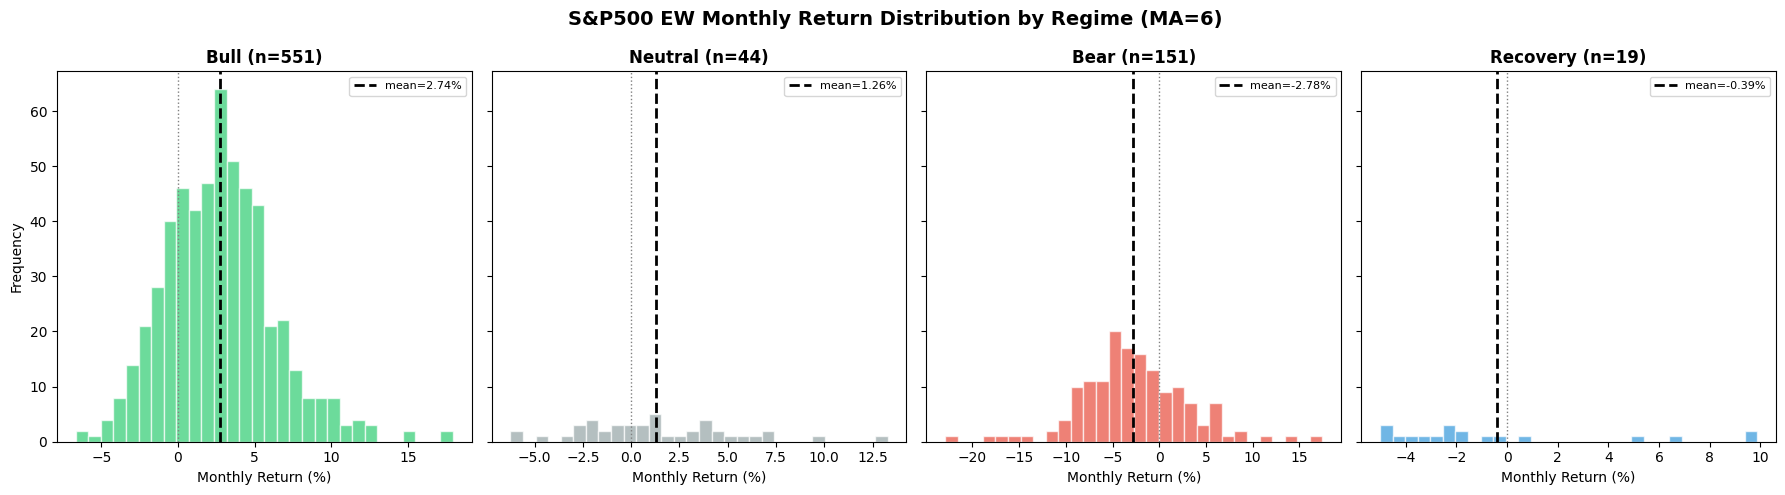


셀 5 완료 — 레짐별 수익률 + 전환 매트릭스 OK


In [7]:
# ── 셀 5: 전체 결과 비교 (레짐 분포, 전환 빈도, 안정성) ─────────────────
# 최종 후보: MA(6) 단일 확정, 레짐별 수익률 비교
# =============================================================================

# ── MA(6) 레짐 확정 ──
regime_final = calc_regime_4(price, ma_window=6, mom_window=3, dd_threshold=-0.10)
regime_col = "regime"

# ── 월간 EW 수익률 merge ──
ew_ret_monthly = ew_monthly["ew_price"].pct_change().to_frame("ew_ret")
regime_final = regime_final.join(ew_ret_monthly)
regime_final = regime_final.dropna(subset=["ew_ret"])

print("=" * 70)
print("레짐별 EW 수익률 통계 (MA=6, 4-Regime)")
print("=" * 70)

stats_rows = []
for regime in ["Bull", "Bear", "Recovery", "Neutral"]:
    mask = regime_final[regime_col] == regime
    rets = regime_final.loc[mask, "ew_ret"]
    
    row = {
        "regime": regime,
        "n_months": len(rets),
        "mean_ret(%)": rets.mean() * 100,
        "median_ret(%)": rets.median() * 100,
        "std(%)": rets.std() * 100,
        "sharpe_ann": (rets.mean() / rets.std()) * np.sqrt(12) if rets.std() > 0 else 0,
        "hit_rate(%)": (rets > 0).mean() * 100,
        "worst(%)": rets.min() * 100,
        "best(%)": rets.max() * 100,
    }
    stats_rows.append(row)

# 전체도 추가
rets_all = regime_final["ew_ret"]
stats_rows.append({
    "regime": "ALL",
    "n_months": len(rets_all),
    "mean_ret(%)": rets_all.mean() * 100,
    "median_ret(%)": rets_all.median() * 100,
    "std(%)": rets_all.std() * 100,
    "sharpe_ann": (rets_all.mean() / rets_all.std()) * np.sqrt(12),
    "hit_rate(%)": (rets_all > 0).mean() * 100,
    "worst(%)": rets_all.min() * 100,
    "best(%)": rets_all.max() * 100,
})

stats_df = pd.DataFrame(stats_rows).set_index("regime")
print(stats_df.round(2).to_string())
print()

# ── 레짐 전환 매트릭스 (어디서 어디로 가는지) ──
print("=" * 70)
print("레짐 전환 매트릭스 (from → to, 횟수)")
print("=" * 70)

regimes_series = regime_final[regime_col]
from_regime = regimes_series.shift(1)
to_regime = regimes_series

transition = pd.crosstab(from_regime, to_regime, margins=True)
print(transition.to_string())
print()

# ── 레짐 전환 매트릭스 (확률, %) ──
print("레짐 전환 확률 (%, 행 기준):")
trans_pct = pd.crosstab(from_regime, to_regime, normalize="index") * 100
print(trans_pct.round(1).to_string())
print()

# ── 시각화: 레짐별 수익률 분포 ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
regime_order = ["Bull", "Neutral", "Bear", "Recovery"]
colors = {"Bull": "#2ecc71", "Bear": "#e74c3c", 
          "Recovery": "#3498db", "Neutral": "#95a5a6"}

for i, regime in enumerate(regime_order):
    ax = axes[i]
    rets = regime_final.loc[regime_final[regime_col] == regime, "ew_ret"] * 100
    ax.hist(rets, bins=30, color=colors[regime], alpha=0.7, edgecolor="white")
    ax.axvline(rets.mean(), color="black", lw=2, ls="--", label=f"mean={rets.mean():.2f}%")
    ax.axvline(0, color="gray", lw=1, ls=":")
    ax.set_title(f"{regime} (n={len(rets)})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Monthly Return (%)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
plt.suptitle("S&P500 EW Monthly Return Distribution by Regime (MA=6)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(INTERIM_DIR / "regime_v4_return_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\n셀 5 완료 — 레짐별 수익률 + 전환 매트릭스 OK")

In [9]:
# ── 셀 5.1: 3레짐 확정 + 수익률 재확인 ──────────────────────────────────
# Recovery → Bear에 흡수, 3개 레짐 최종
# =============================================================================

def calc_regime_3(price_series, ma_window=6, mom_window=3):
    """
    3-regime classification.
    
    Bull:    price > MA  AND  mom > 0
    Neutral: price > MA  AND  mom <= 0
    Bear:    price <= MA (전부)
    
    Bear 내부에서 mom 부호는 별도 컬럼으로 저장 (팩터 가중치 조절용)
    """
    df = pd.DataFrame(index=price_series.index)
    df["price"] = price_series
    
    # MA + 모멘텀
    df["ma"] = df["price"].rolling(ma_window, min_periods=ma_window).mean()
    df["price_vs_ma"] = df["price"] / df["ma"] - 1
    df["mom"] = df["price"].pct_change(mom_window)
    
    # Drawdown (참고용)
    df["drawdown"] = df["price"] / df["price"].expanding().max() - 1
    
    # ── 3개 레짐 ──
    above_ma = df["price_vs_ma"] > 0
    mom_pos = df["mom"] > 0
    
    df["regime"] = "Neutral"  # 기본값: MA 위 + mom <= 0
    df.loc[above_ma & mom_pos, "regime"] = "Bull"
    df.loc[~above_ma, "regime"] = "Bear"
    
    # Bear 내부 세분화 (레짐이 아닌 보조 변수)
    df["bear_phase"] = ""
    bear_mask = df["regime"] == "Bear"
    df.loc[bear_mask & mom_pos, "bear_phase"] = "recovering"
    df.loc[bear_mask & ~mom_pos, "bear_phase"] = "declining"
    
    df = df.dropna(subset=["ma"])
    return df


# ── 3레짐 생성 ──
reg3 = calc_regime_3(price, ma_window=6, mom_window=3)
reg3 = reg3.join(ew_ret_monthly).dropna(subset=["ew_ret"])

print("=" * 70)
print("3-Regime 분포 (MA=6, 모멘텀=3M)")
print("=" * 70)
print(reg3["regime"].value_counts().sort_index())
print()
print("비율 (%):")
print((reg3["regime"].value_counts(normalize=True).sort_index() * 100).round(1))
print()

# ── 레짐별 수익률 ──
print("=" * 70)
print("레짐별 EW 수익률 통계")
print("=" * 70)
stats3 = []
for regime in ["Bull", "Neutral", "Bear"]:
    rets = reg3.loc[reg3["regime"] == regime, "ew_ret"]
    stats3.append({
        "regime": regime,
        "n_months": len(rets),
        "mean_ret(%)": rets.mean() * 100,
        "std(%)": rets.std() * 100,
        "sharpe_ann": (rets.mean() / rets.std()) * np.sqrt(12) if rets.std() > 0 else 0,
        "hit_rate(%)": (rets > 0).mean() * 100,
    })
stats3_df = pd.DataFrame(stats3).set_index("regime")
print(stats3_df.round(2).to_string())
print()

# ── Bear 내부: declining vs recovering ──
print("=" * 70)
print("Bear 내부 세분화 (보조 변수)")
print("=" * 70)
bear_data = reg3[reg3["regime"] == "Bear"]
for phase in ["declining", "recovering"]:
    rets = bear_data.loc[bear_data["bear_phase"] == phase, "ew_ret"]
    if len(rets) > 0:
        print(f"  {phase:12s}: n={len(rets):3d}  mean={rets.mean()*100:+.2f}%  "
              f"std={rets.std()*100:.2f}%  hit_rate={((rets>0).mean()*100):.1f}%")
print()

# ── 전환 매트릭스 ──
print("전환 확률 (%, 행 기준):")
trans3 = pd.crosstab(reg3["regime"].shift(1), reg3["regime"], normalize="index") * 100
print(trans3.round(1).to_string())
print()

# ── 전환 빈도 ──
switches3 = (reg3["regime"] != reg3["regime"].shift()).sum() - 1
print(f"전환빈도: {switches3/len(reg3):.3f}  |  평균체류: {len(reg3)/(switches3+1):.1f}개월")

print("\n셀 5.1 완료 — 3레짐 확정 OK")

3-Regime 분포 (MA=6, 모멘텀=3M)
regime
Bear       170
Bull       551
Neutral     44
Name: count, dtype: int64

비율 (%):
regime
Bear       22.2
Bull       72.0
Neutral     5.8
Name: proportion, dtype: float64

레짐별 EW 수익률 통계
         n_months  mean_ret(%)  std(%)  sharpe_ann  hit_rate(%)
regime                                                         
Bull          551         2.74    3.56        2.67        77.13
Neutral        44         1.26    4.02        1.09        59.09
Bear          170        -2.51    5.69       -1.53        27.65

Bear 내부 세분화 (보조 변수)
  declining   : n=151  mean=-2.78%  std=5.77%  hit_rate=27.8%
  recovering  : n= 19  mean=-0.39%  std=4.67%  hit_rate=26.3%

전환 확률 (%, 행 기준):
regime   Bear  Bull  Neutral
regime                      
Bear     62.9  27.1     10.0
Bull      8.5  87.5      4.0
Neutral  34.1  54.5     11.4

전환빈도: 0.224  |  평균체류: 4.4개월

셀 5.1 완료 — 3레짐 확정 OK


In [10]:
# ── 셀 6: 거시 필터 일치율 ───────────────────────────────────────────────
# 3레짐(시장 기반) vs 거시 지표 방향 일치율 확인
# =============================================================================

# ── 거시 지표 로드 (셀 1에서 이미 로드됨) ──
# macro: UNRATE, T10Y2Y, T10Y3M, BAMLH0A0HYM2, VIXCLS, FEDFUNDS, CPIAUCSL

# ── 거시 지표를 월말로 리샘플 + 시그널화 ──
macro_m = macro.resample("ME").last()

# 거시 시그널 정의 (Bear 방향 = True)
macro_signals = pd.DataFrame(index=macro_m.index)

# 1. BAA 스프레드 (하이일드 스프레드): 상승 = 위험 증가 = Bear 방향
macro_signals["baa_rising"] = macro_m["BAMLH0A0HYM2"].diff(3) > 0

# 2. 실업률 변화: 상승 = 경기 둔화 = Bear 방향
macro_signals["unrate_rising"] = macro_m["UNRATE"].diff(3) > 0

# 3. 장단기 금리차 (10Y-2Y): 하락/역전 = Bear 방향
macro_signals["yield_curve_flat"] = macro_m["T10Y2Y"] < 0.5

# 4. VIX: 높으면 = Bear 방향
macro_signals["vix_high"] = macro_m["VIXCLS"] > 20

# 5. 10Y-3M 금리차: 역전 = Bear 방향
macro_signals["t10y3m_inv"] = macro_m["T10Y3M"] < 0

# ── 레짐과 merge ──
reg3_regime = reg3[["regime", "bear_phase"]].copy()
merged = reg3_regime.join(macro_signals, how="inner")
merged["is_bear"] = merged["regime"] == "Bear"

print("=" * 70)
print("거시 필터 vs 3-Regime 일치율")
print("=" * 70)
print(f"공통 기간: {merged.index.min().strftime('%Y-%m')} ~ "
      f"{merged.index.max().strftime('%Y-%m')} ({len(merged)}개월)")
print()

# ── 각 거시 시그널별 일치율 ──
signal_cols = ["baa_rising", "unrate_rising", "yield_curve_flat", 
               "vix_high", "t10y3m_inv"]
signal_names = ["BAA 스프레드 상승(3M)", "실업률 상승(3M)", 
                "장단기차 <0.5%", "VIX >20", "10Y-3M 역전"]

print(f"{'거시 시그널':<22s} {'Bear일치':>8s} {'Bull일치':>8s} "
      f"{'정밀도':>8s} {'재현율':>8s}")
print("-" * 60)

for col, name in zip(signal_cols, signal_names):
    valid = merged[[col, "is_bear"]].dropna()
    if len(valid) == 0:
        continue
    
    # 시그널 ON일 때 실제 Bear인 비율 (정밀도)
    sig_on = valid[col] == True
    if sig_on.sum() > 0:
        precision = valid.loc[sig_on, "is_bear"].mean() * 100
    else:
        precision = 0
    
    # Bear일 때 시그널 ON인 비율 (재현율)
    bear_mask = valid["is_bear"] == True
    if bear_mask.sum() > 0:
        recall = valid.loc[bear_mask, col].mean() * 100
    else:
        recall = 0
    
    # 전체 일치율 (시그널 방향 = 레짐 방향)
    agree = ((valid[col] == True) & (valid["is_bear"] == True)) | \
            ((valid[col] == False) & (valid["is_bear"] == False))
    accuracy = agree.mean() * 100
    
    # Bull일 때 시그널 OFF 비율
    bull_mask = valid["is_bear"] == False
    if bull_mask.sum() > 0:
        bull_agree = (valid.loc[bull_mask, col] == False).mean() * 100
    else:
        bull_agree = 0
    
    print(f"{name:<22s} {accuracy:>7.1f}% {bull_agree:>7.1f}% "
          f"{precision:>7.1f}% {recall:>7.1f}%")

print()
print("정밀도 = 시그널 ON일 때 실제 Bear인 비율")
print("재현율 = Bear일 때 시그널 ON인 비율")
print()

# ── 복합 거시 필터: N개 이상 동시 ON ──
print("=" * 70)
print("복합 거시 필터: N개 이상 동시 ON일 때")
print("=" * 70)

valid_all = merged[signal_cols + ["is_bear"]].dropna()
n_signals_on = valid_all[signal_cols].sum(axis=1)

for threshold in [1, 2, 3, 4, 5]:
    mask = n_signals_on >= threshold
    if mask.sum() == 0:
        continue
    prec = valid_all.loc[mask, "is_bear"].mean() * 100
    n_months = mask.sum()
    # Bear일 때 이 조건 충족 비율
    bear_m = valid_all["is_bear"] == True
    if bear_m.sum() > 0:
        rec = (mask & bear_m).sum() / bear_m.sum() * 100
    else:
        rec = 0
    print(f"  {threshold}개 이상 ON: {n_months:3d}개월  |  "
          f"정밀도={prec:.1f}%  재현율={rec:.1f}%")

print("\n셀 6 완료 — 거시 필터 일치율 OK")

거시 필터 vs 3-Regime 일치율
공통 기간: 2000-01 ~ 2026-02 (314개월)

거시 시그널                   Bear일치   Bull일치      정밀도      재현율
------------------------------------------------------------
BAA 스프레드 상승(3M)           72.0%    69.3%    37.8%    84.2%
실업률 상승(3M)                67.2%    72.4%    26.0%    43.9%
장단기차 <0.5%                61.1%    66.5%    19.6%    36.8%
VIX >20                   75.2%    73.2%    41.0%    84.2%
10Y-3M 역전                 69.1%    81.3%    14.3%    14.0%

정밀도 = 시그널 ON일 때 실제 Bear인 비율
재현율 = Bear일 때 시그널 ON인 비율

복합 거시 필터: N개 이상 동시 ON일 때
  1개 이상 ON: 238개월  |  정밀도=23.9%  재현율=100.0%
  2개 이상 ON: 165개월  |  정밀도=31.5%  재현율=91.2%
  3개 이상 ON:  77개월  |  정밀도=40.3%  재현율=54.4%
  4개 이상 ON:  20개월  |  정밀도=40.0%  재현율=14.0%
  5개 이상 ON:   3개월  |  정밀도=66.7%  재현율=3.5%

셀 6 완료 — 거시 필터 일치율 OK


In [11]:
# ── 셀 7: 최종 선택 + regime_v4.parquet 저장 ─────────────────────────────
# =============================================================================

# ── 최종 레짐: 3-Regime (MA=6, mom=3M) ──
reg_final = calc_regime_3(price, ma_window=6, mom_window=3)

# ── 거시 필터 merge ──
macro_m = macro.resample("ME").last()

reg_final["baa_rising"] = macro_m["BAMLH0A0HYM2"].diff(3).reindex(reg_final.index) > 0
reg_final["unrate_rising"] = macro_m["UNRATE"].diff(3).reindex(reg_final.index) > 0
reg_final["yield_curve_flat"] = macro_m["T10Y2Y"].reindex(reg_final.index) < 0.5
reg_final["vix_high"] = macro_m["VIXCLS"].reindex(reg_final.index) > 20
reg_final["t10y3m_inv"] = macro_m["T10Y3M"].reindex(reg_final.index) < 0

# 거시 필터 카운트 (N개 ON)
filter_cols = ["baa_rising", "unrate_rising", "yield_curve_flat", "vix_high", "t10y3m_inv"]
reg_final["macro_bear_count"] = reg_final[filter_cols].sum(axis=1)

# 거시 확신도 등급
reg_final["macro_confirm"] = "none"
reg_final.loc[reg_final["macro_bear_count"] >= 1, "macro_confirm"] = "weak"
reg_final.loc[reg_final["macro_bear_count"] >= 3, "macro_confirm"] = "moderate"
reg_final.loc[reg_final["macro_bear_count"] >= 4, "macro_confirm"] = "strong"

# ── 저장할 컬럼 정리 ──
save_cols = [
    "price", "ma", "price_vs_ma", "mom", "drawdown",
    "regime", "bear_phase",
    "macro_bear_count", "macro_confirm",
]
out = reg_final[save_cols].copy()

# ── 저장 ──
OUT_PATH = INTERIM_DIR / "regime_v4.parquet"
out.to_parquet(OUT_PATH, engine="pyarrow")

print("=" * 70)
print("regime_v4.parquet 저장 완료")
print("=" * 70)
print(f"경로: {OUT_PATH}")
print(f"Shape: {out.shape}")
print(f"기간: {out.index.min().strftime('%Y-%m')} ~ {out.index.max().strftime('%Y-%m')}")
print(f"총 {len(out)}개월")
print()

print("컬럼 설명:")
print("  price         : EW 월말 가격")
print("  ma            : 6개월 SMA")
print("  price_vs_ma   : 가격/MA - 1 (양수=MA 위)")
print("  mom           : 3개월 모멘텀")
print("  drawdown      : 전고점 대비 DD")
print("  regime        : Bull / Neutral / Bear")
print("  bear_phase    : Bear 내부 — declining(mom<0) / recovering(mom>0)")
print("  macro_bear_count : 거시 Bear 시그널 ON 개수 (0~5)")
print("  macro_confirm : 거시 확신도 — none / weak / moderate / strong")
print()

print("레짐 분포:")
print(out["regime"].value_counts().sort_index().to_string())
print()

print("Bear 내부:")
bear_only = out[out["regime"] == "Bear"]
print(bear_only["bear_phase"].value_counts().to_string())
print()

print("거시 확신도 분포:")
print(out["macro_confirm"].value_counts().reindex(["none","weak","moderate","strong"]).to_string())
print()

# ── 최종 요약 ──
print("=" * 70)
print("01_DataLoader_Regime.ipynb 최종 요약")
print("=" * 70)
print("""
[레짐 분류]
  방법: 3-Regime (MA=6, 모멘텀=3M)
  Bull:    MA 위 + mom > 0    (~72%)
  Neutral: MA 위 + mom <= 0   (~6%)
  Bear:    MA 아래 전부        (~22%)

[Bear 내부 보조 변수]
  declining:  mom < 0  (하락 지속) → D-1, F-1 메인
  recovering: mom > 0  (반등 중)  → A-3 비중 추가

[거시 필터 (확인/경고용)]
  5개 시그널: BAA↑, 실업률↑, 장단기차<0.5, VIX>20, 10Y3M역전
  3개 이상 ON → Bear 확신도 moderate (정밀도 40%, 재현율 54%)
  
[팩터 매핑]
  Bull:    H-1(메인), P-7(보조), T-1a(보조시그널)
  Neutral: D-3 + A-3 + H-1(메인), P-7(보조), T-1b(보조시그널)
  Bear:    D-1 + H-1(메인), F-1(필터), P-7(보조)
           → bear_phase=recovering 시 A-3 비중 추가

[산출물]
  data/interim/regime_v4.parquet
""")

print("셀 7 완료 — 노트북 종료")

regime_v4.parquet 저장 완료
경로: C:\QP2\data\interim\regime_v4.parquet
Shape: (765, 9)
기간: 1962-06 ~ 2026-02
총 765개월

컬럼 설명:
  price         : EW 월말 가격
  ma            : 6개월 SMA
  price_vs_ma   : 가격/MA - 1 (양수=MA 위)
  mom           : 3개월 모멘텀
  drawdown      : 전고점 대비 DD
  regime        : Bull / Neutral / Bear
  bear_phase    : Bear 내부 — declining(mom<0) / recovering(mom>0)
  macro_bear_count : 거시 Bear 시그널 ON 개수 (0~5)
  macro_confirm : 거시 확신도 — none / weak / moderate / strong

레짐 분포:
regime
Bear       170
Bull       551
Neutral     44

Bear 내부:
bear_phase
declining     151
recovering     19

거시 확신도 분포:
macro_confirm
none        527
weak        161
moderate     57
strong       20

01_DataLoader_Regime.ipynb 최종 요약

[레짐 분류]
  방법: 3-Regime (MA=6, 모멘텀=3M)
  Bull:    MA 위 + mom > 0    (~72%)
  Neutral: MA 위 + mom <= 0   (~6%)
  Bear:    MA 아래 전부        (~22%)

[Bear 내부 보조 변수]
  declining:  mom < 0  (하락 지속) → D-1, F-1 메인
  recovering: mom > 0  (반등 중)  → A-3 비중 추가

[거시 필터 (확인/경고용)]
  5개 시그널: BAA↑, 실업